# Human SAN — Spontaneous Spiking with Rate-Addend Forcing (JAX + diffrax)

Same Fabbri-Fantini-Wilders-Severi 2017 human sinoatrial-node model as the
NumPy example, but compiled with `backend="jax"` and integrated with
**diffrax** instead of scipy.

$$\frac{dV}{dt}\bigg|_{\text{total}} = \frac{dV}{dt}\bigg|_{\text{model}} + f(t)$$

**Requirements:** `pip install cellml2py[jax]` (installs jax, jaxlib, diffrax).

In [8]:
import sys
import pathlib
import numpy as np
import jax
import jax.numpy as jnp
import diffrax

_root = next(
    p
    for p in [pathlib.Path.cwd(), pathlib.Path.cwd().parent]
    if (p / "src" / "cellml2py").exists()
)
if str(_root / "examples") not in sys.path:
    sys.path.insert(0, str(_root / "examples"))

print(f"JAX version: {jax.__version__}")
print(f"diffrax version: {diffrax.__version__}")
print(f"default backend: {jax.default_backend()}")

JAX version: 0.10.0
diffrax version: 0.7.2
default backend: cpu


In [9]:
from cellml2py import CompileOptions, OverrideSpec, compile_cellml, simulate_diffrax
from example_utils import build_injection_current, plot_voltage_and_current

In [10]:
# --- compile with rate_addend override on membrane voltage (JAX backend) ---
model_path = _root / "data/HumanSAN_Fabbri_Fantini_Wilders_Severi_2017.cellml"

options = CompileOptions(
    override_targets=(OverrideSpec(target="V_ode", kind="rate_addend"),),
    sanitize_nan=True,  # required for diffrax: replaces NaN/Inf rates with 0
                        # so the implicit Newton solver stays numerically stable
)
model = compile_cellml(model_path, backend="jax", options=options)
print(
    f"compiled  states={model.initial_state.size}  "
    f"backend={model.backend}  forcing={model.layout.forcing_names}"
)

compiled  states=33  backend=jax  forcing=('V_ode',)


In [11]:
# --- forcing settings ---
# forcing_mode: 'ramp', 'constant', or 'pulse'
forcing_mode = "ramp"

# ramp: linearly sweeps from ramp_i_start to ramp_i_end over [ramp_start, ramp_end]
# Units: mV/s added to dV/dt  (V_ode is in mV, time in s).
# Baseline dV/dt is ~60-100 mV/s, so values of ±50-200 mV/s are clearly visible.
ramp_start = 0.0    # s — time the ramp begins
ramp_end   = 4.0    # s — time the ramp ends
ramp_i_start = 0.0  # mV/s addend at ramp_start
ramp_i_end   = 100.0  # mV/s addend at ramp_end  (~5.7 pA equivalent)

# constant / pulse fallback settings (unused when forcing_mode = 'ramp')
constant_current = 0.0
amp          = 100.0
pulse_start  = 0.5
pulse_width  = 0.05
pulse_interval = 0.8
n_pulses     = 2

i_inj = build_injection_current(
    forcing_mode,
    constant_current,
    amp,
    pulse_start,
    pulse_width,
    pulse_interval,
    n_pulses,
    ramp_start=ramp_start,
    ramp_end=ramp_end,
    ramp_i_start=ramp_i_start,
    ramp_i_end=ramp_i_end,
)

In [12]:
# --- diffrax solver settings ---
t_end  = 4.0   # s
steps  = 1001

# Kvaerno5 is a 5th-order implicit Runge-Kutta method — stiffly stable,
# well-suited to the stiff SAN ion-channel kinetics.
solver = diffrax.Tsit5()
controller = diffrax.PIDController(rtol=1e-5, atol=1e-7, dtmin=1e-5)  # allow very small steps for rapid voltage changes

sol = simulate_diffrax(
    model,
    (0.0, t_end),
    steps=steps,
    forcing=lambda t: [i_inj(t)],
    solver=solver,
    stepsize_controller=controller,
    max_steps=2**18,
    jit=True,  # compile with JIT
)
print(f"result={sol.result}   samples={sol.ts.shape[0]}")

result=diffrax._solution.RESULTS<>   samples=1001


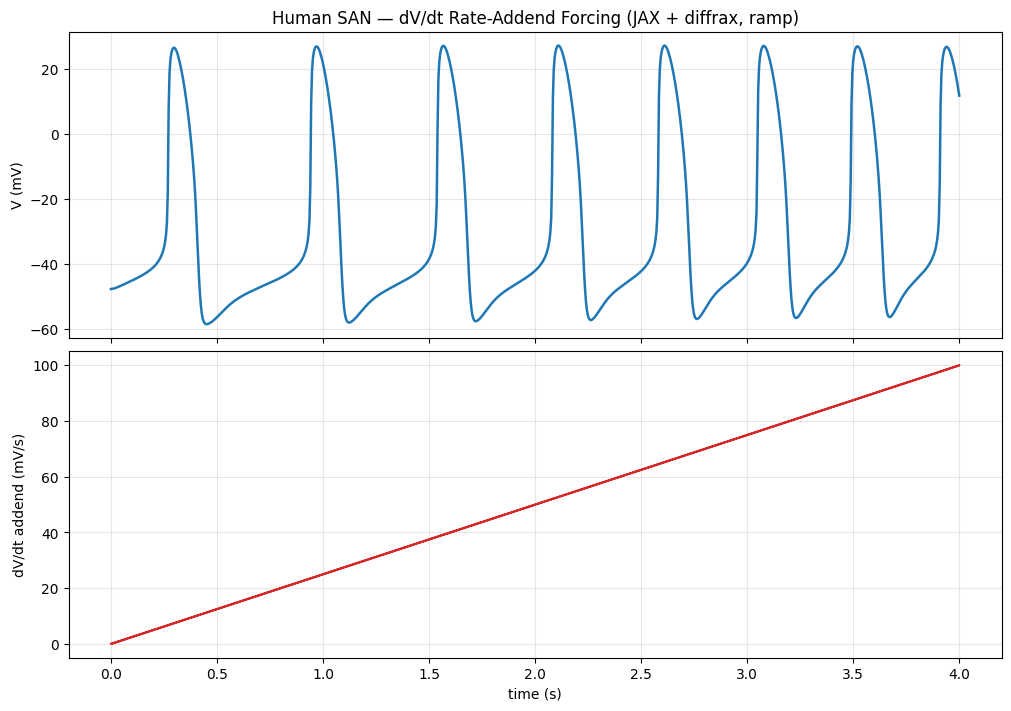

WindowsPath('san_spiking_forced_jax.png')

In [13]:
# sol.ts has shape (steps,) and sol.ys has shape (steps, n_states)
t_arr = np.asarray(sol.ts)
y_arr = np.asarray(sol.ys)   # (steps, n_states)

# State index 0 is V (membrane voltage)
v_trace = y_arr[:, 0]
current_trace = np.array([i_inj(float(t)) for t in t_arr])

plot_voltage_and_current(
    t_arr,
    v_trace,
    current_trace,
    title="Human SAN — dV/dt Rate-Addend Forcing (JAX + diffrax, ramp)",
    time_label="time (s)",
    current_label="dV/dt addend (mV/s)",
    plot_path="san_spiking_forced_jax.png",
    show=True,
)

## Optional: JIT-compile the RHS and benchmark

Because `backend="jax"`, the RHS is fully traceable.  You can JIT-compile the
entire solve — including the diffrax integration loop — for a significant
speedup on repeated calls (e.g. parameter fitting).

In [14]:
import time

rhs = model.make_rhs()
x0  = jnp.asarray(model.initial_state)

# --- smoke test: single JIT-compiled RHS call ---
rhs_jit = jax.jit(rhs)
dx = rhs_jit(0.0, x0, (None, [0.0]))
print(f"JIT RHS output shape: {dx.shape}   first two values: {dx[:2]}")

# --- JIT the entire diffrax solve (no forcing, unperturbed model) ---
@jax.jit
def _solve_jit(y0):
    term = diffrax.ODETerm(rhs)
    saveat = diffrax.SaveAt(ts=jnp.linspace(0.0, t_end, steps))
    return diffrax.diffeqsolve(
        term,
        diffrax.Tsit5(),
        t0=0.0,
        t1=t_end,
        dt0=(t_end / steps),
        y0=y0,
        args=(None, [0.0]),  # no forcing — zero addend to V_ode rate
        saveat=saveat,
        stepsize_controller=diffrax.PIDController(rtol=1e-6, atol=1e-8, dtmin=t_end / 100_000),
        max_steps=2**18,
    )

# First call triggers compilation
t0 = time.perf_counter()
sol_jit = _solve_jit(x0)
sol_jit.ys.block_until_ready()
compile_time = time.perf_counter() - t0

# Second call is the compiled path
t0 = time.perf_counter()
sol_jit2 = _solve_jit(x0)
sol_jit2.ys.block_until_ready()
run_time = time.perf_counter() - t0

print(f"JIT compile+run: {compile_time:.2f}s   subsequent run: {run_time:.3f}s")
print(f"result={sol_jit2.result}")


JIT RHS output shape: (33,)   first two values: [67.38155   -1.5731646]
JIT compile+run: 3.72s   subsequent run: 0.570s
result=diffrax._solution.RESULTS<>


## Overriding a constant parameter: ACh (vagal modulation)

`ACh` (acetylcholine, in millimolar) is declared as a **constant**
(`initial_value="0"`) in the CellML model.  A constant carries no ODE rate
expression, so the correct override kind is `"constant"` — the supplied
forcing value **replaces** the constant inside every RHS call.

Physiological range: 0 mM (no vagal tone, fast rate) → ~0.01 mM (strong vagal
stimulation, rate slowing of ~20-40 %).

```python
OverrideSpec(target="ACh", kind="constant")
```

The forcing callable must return one value per override target; here it
returns a simple Heaviside step — JAX-traceable because it avoids Python
`if`-branches on `t`.


In [15]:
# --- compile with ACh as a constant override target ---
model_ach = compile_cellml(
    model_path,
    backend="jax",
    options=CompileOptions(
        override_targets=(OverrideSpec(target="ACh", kind="constant"),),
        sanitize_nan=True,
    ),
)
print(
    f"compiled  states={model_ach.initial_state.size}  "
    f"forcing names: {model_ach.layout.forcing_names}"
)


compiled  states=33  forcing names: ('ACh',)


In [19]:
# --- ACh step: 0 mM for the first 2 s, then 10 nM (strong vagal tone) ---
t_switch = 2.0
ach_high  = 0.00001   # mM (10 nM)

# Heaviside step — JAX-traceable: comparison returns a JAX bool, no Python if.
ach_forcing = lambda t: [ach_high * (t >= t_switch)]

sol_ach = simulate_diffrax(
    model_ach,
    (0.0, t_end),          # reuse t_end = 4.0 s from earlier
    steps=steps,
    forcing=ach_forcing,
    solver=solver,
    stepsize_controller=controller,
    max_steps=2**18,
    jit=True,  # compile with JIT
)
print(f"result={sol_ach.result}   samples={sol_ach.ts.shape[0]}")


result=diffrax._solution.RESULTS<>   samples=1001


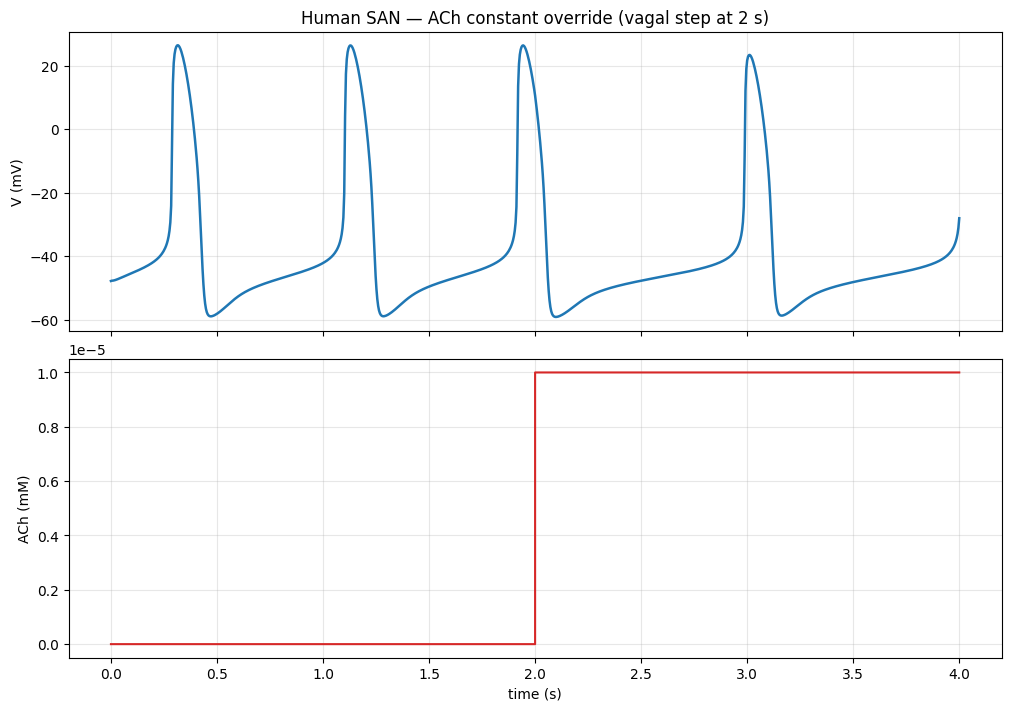

WindowsPath('san_ach_step_jax.png')

In [20]:
t_ach   = np.asarray(sol_ach.ts)
y_ach   = np.asarray(sol_ach.ys)
v_ach   = y_ach[:, 0]
ach_trace = np.array([float(ach_high * (t >= t_switch)) for t in t_ach])

plot_voltage_and_current(
    t_ach,\
    v_ach,
    ach_trace,
    title="Human SAN — ACh constant override (vagal step at 2 s)",
    time_label="time (s)",
    current_label="ACh (mM)",
    plot_path="san_ach_step_jax.png",
    show=True,
)
